# Task 3: GNN–BERT Fusion for Multi-Context Music Understanding
## Section 1: Project Overview

This notebook implements the complete research pipeline for **Task 3: GNN–BERT Fusion for Multi-Context Music Understanding** on Kaggle using the **FMA-medium** dataset.

### Core Objectives:
1. **Audio/Music Structure -> Graph -> GNN**: Construct a graph where nodes represent temporal audio segments and edges capture temporal adjacency and acoustic similarity. Process this with GraphSAGE / GAT.
2. **Textual Music Context -> BERT**: Extract contextual, non-leaky metadata (title, artist, recording arrangement, audience reception) and encode with DistilBERT.
3. **Multimodal Fusion & Multi-Label Prediction**: Formulate a scientifically sound fusion mechanism for multi-label genre and music context prediction.
4. **Strict Pairing**: Audio, graph, text, and ground truth labels must belong to the **SAME** FMA-medium track.
5. **Ablation Comparison**:
   - **Model A**: BERT-only baseline
   - **Model B**: GNN-only baseline
   - **Model C**: Early-concatenation GNN+BERT ($z = [g \,;\, t]$)
   - **Model D**: Cross-attention GNN+BERT ($Q = g W_Q, K = H_{text} W_K, V = H_{text} W_V$)

All four models are trained on the **identical train/validation/test splits**, use the **exact same targets**, and are evaluated with the **same metrics** (Macro-F1, Micro-F1, AUC-PR).


## Section 2: Imports and Configuration
We check environment prerequisites, configure GPU acceleration, define hyperparameters, and establish a feature caching strategy to ensure computational feasibility on Kaggle.


In [1]:
import os
import sys
import glob
import ast
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Optional audio loading
try:
    import torchaudio
    import torchaudio.transforms as T
    HAS_TORCHAUDIO = True
except ImportError:
    HAS_TORCHAUDIO = False

try:
    import librosa
    HAS_LIBROSA = True
except ImportError:
    HAS_LIBROSA = False

# Transformers
try:
    from transformers import AutoTokenizer, AutoModel
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers"])
    from transformers import AutoTokenizer, AutoModel

# PyTorch Geometric
try:
    import torch_geometric
    from torch_geometric.data import Data, Batch
    from torch_geometric.nn import SAGEConv, GATConv, global_mean_pool, global_max_pool
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch_geometric"])
    import torch_geometric
    from torch_geometric.data import Data, Batch
    from torch_geometric.nn import SAGEConv, GATConv, global_mean_pool, global_max_pool

from sklearn.metrics import f1_score, precision_recall_fscore_support, average_precision_score
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")

# Global Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# GPU Detection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device selected: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"VRAM Allocated: {torch.cuda.memory_allocated(0)/(1024**2):.2f} MB")
    print(f"VRAM Reserved:  {torch.cuda.memory_reserved(0)/(1024**2):.2f} MB")

class Config:
    KAGGLE_INPUT_DIR = Path("/kaggle/input")
    OUTPUT_DIR = Path("/kaggle/working")
    CACHE_DIR = Path("/kaggle/working/feature_cache")
    
    # Audio parameters
    SAMPLE_RATE = 22050
    SEGMENT_DURATION_SEC = 5.0  # 5-second window per node
    HOP_LENGTH = 512
    N_MELS = 64
    N_CHROMA = 12
    FEATURE_DIM = N_MELS + N_CHROMA  # 76-dimensional feature vector per node
    MAX_SEGMENTS = 6                 # 30s track / 5s = 6 segments (nodes)
    SIMILARITY_THRESHOLD = 0.75      # Cosine similarity threshold for edges
    
    # Text parameters
    BERT_MODEL_NAME = "distilbert-base-uncased"
    MAX_TEXT_LEN = 128
    
    # Model architecture parameters
    HIDDEN_DIM = 128
    NUM_GNN_LAYERS = 2
    GNN_TYPE = "GraphSAGE"           # "GraphSAGE" or "GAT"
    NUM_ATTENTION_HEADS = 4
    DROPOUT = 0.3
    
    # Training parameters
    BATCH_SIZE = 16
    LEARNING_RATE = 2e-4
    WEIGHT_DECAY = 1e-4
    NUM_EPOCHS = 8
    PATIENCE = 3                     # Early stopping patience
    
    # Dataset Cohort Size (Set to an integer like 1200 or 2500 for fast verification, or None for all available tracks)
    SUBSET_SIZE = None
    TOP_K_GENRES = 10                # Multi-label top-K targets
    ENABLE_CACHE = True              # Cache extracted features to prevent redundant MP3 decoding

cfg = Config()
os.makedirs(cfg.CACHE_DIR, exist_ok=True)
print("Configuration loaded successfully. Feature cache initialized at:", cfg.CACHE_DIR)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.2 MB/s eta 0:00:00
Device selected: cuda
GPU Model: Tesla T4
VRAM Allocated: 0.00 MB
VRAM Reserved:  0.00 MB
Configuration loaded successfully. Feature cache initialized at: /kaggle/working/feature_cache


## Section 3: Kaggle Dataset Inspection
We dynamically scan the Kaggle input environment to discover `tracks.csv`, `genres.csv`, and the root audio folders.


In [2]:
def inspect_kaggle_input(base_dir=Config.KAGGLE_INPUT_DIR):
    discovered = {"tracks_csv": None, "genres_csv": None, "audio_dir": None}
    print(f"Scanning base directory: {base_dir}")
    
    if not os.path.exists(base_dir):
        print(f"Directory {base_dir} does not exist locally. Falling back to local workspace.")
        base_dir = Path(".")
        
    for root, dirs, files in os.walk(base_dir):
        for f in files:
            fl = f.lower()
            if fl == "tracks.csv" and not discovered["tracks_csv"]:
                discovered["tracks_csv"] = os.path.join(root, f)
            elif fl == "genres.csv" and not discovered["genres_csv"]:
                discovered["genres_csv"] = os.path.join(root, f)
        for d in dirs:
            dl = d.lower()
            if any(k in dl for k in ["fma_medium", "fma_small", "fma_large"]) and not discovered["audio_dir"]:
                discovered["audio_dir"] = os.path.join(root, d)

    print("\n=== Kaggle Discovery Summary ===")
    for k, v in discovered.items():
        print(f"  {k:12s}: {v}")
    return discovered

def build_audio_file_index(audio_dir):
    """Scan audio_dir once and map zero-padded track id (filename stem) -> real file path.
    This avoids assuming a specific folder-depth convention (e.g. 'xxx/xxxxxx.mp3'), which
    silently breaks path guessing and forces every track into the synthetic audio fallback."""
    index = {}
    if not audio_dir or not os.path.exists(audio_dir):
        print("No valid audio_dir to index; audio features will use the synthetic fallback for ALL tracks.")
        return index
    for root, _dirs, files in os.walk(audio_dir):
        for f in files:
            if f.lower().endswith(".mp3"):
                stem = os.path.splitext(f)[0]
                index[stem] = os.path.join(root, f)
    return index

kaggle_paths = inspect_kaggle_input()

print(f"\nlibrosa available: {HAS_LIBROSA} (if False, ALL tracks silently use the synthetic audio fallback)")
print("Indexing audio files under the discovered audio_dir...")
audio_file_index = build_audio_file_index(kaggle_paths["audio_dir"])
print(f"Indexed {len(audio_file_index)} real audio files.")
if audio_file_index:
    sample_keys = list(audio_file_index.keys())[:3]
    print("Sample indexed track id(s):", sample_keys)
    print("Sample resolved path:      ", audio_file_index[sample_keys[0]])
else:
    print("WARNING: audio index is empty. Every track will fall back to a synthetic sine-tone "
          "feature keyed only by track_id — the GNN branch will carry no genuine genre signal.")



Scanning base directory: /kaggle/input

=== Kaggle Discovery Summary ===
  tracks_csv  : /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_metadata/tracks.csv
  genres_csv  : /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_metadata/genres.csv
  audio_dir   : /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_medium

librosa available: True (if False, ALL tracks silently use the synthetic audio fallback)
Indexing audio files under the discovered audio_dir...
Indexed 25000 real audio files.
Sample indexed track id(s): ['135004', '135369', '135374']
Sample resolved path:       /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_medium/fma_medium/135/135004.mp3


## Section 4: FMA-medium Metadata Inspection
`tracks.csv` in FMA contains 3-level MultiIndex headers:
- Level 0: Category (`track`, `album`, `artist`)
- Level 1: Field name (`genre_top`, `genres`, `title`, `information`, etc.)
We parse this structure and select columns for track IDs, genre labels, and non-leaky contextual metadata.


In [3]:
def load_and_inspect_metadata(tracks_path):
    if tracks_path is None or not os.path.exists(tracks_path):
        print("tracks.csv not found on disk. Generating representative mock metadata matching FMA schema.")
        cohort_len = Config.SUBSET_SIZE if Config.SUBSET_SIZE is not None else 1200
        track_ids = list(range(1001, 1001 + cohort_len))
        sample_genres = ["Rock", "Electronic", "Experimental", "Hip-Hop", "Folk", "Pop", "Classical", "Jazz", "International", "Instrumental"]
        data = {
            "track_id": track_ids,
            "genre_top": [random.choice(sample_genres) for _ in track_ids],
            "genres_all": [str([random.randint(1, 15) for _ in range(random.randint(1, 3))]) for _ in track_ids],
            "track_title": [f"Piece Opus {i}" for i in track_ids],
            "artist_name": [f"Artist_{i%35}" for i in track_ids],
            "track_information": [f"Studio recording production arranged in acoustic space #{i%10}" for i in track_ids],
            "track_interest": np.random.randint(50, 10000, size=len(track_ids)),
            "track_listens": np.random.randint(100, 50000, size=len(track_ids)),
            "track_favorites": np.random.randint(1, 500, size=len(track_ids)),
        }
        df = pd.DataFrame(data).set_index("track_id")
        return df

    print(f"Reading FMA MultiIndex metadata from {tracks_path}...")
    raw_tracks = pd.read_csv(tracks_path, index_col=0, header=[0, 1])
    print(f"Raw columns count: {len(raw_tracks.columns)}")
    print("Columns sample:", list(raw_tracks.columns[:8]))
    
    # Filter fma_medium / fma_small subset if present
    if ("set", "subset") in raw_tracks.columns:
        subset_mask = raw_tracks[("set", "subset")].isin(["medium", "small"])
        tracks = raw_tracks[subset_mask].copy()
    else:
        tracks = raw_tracks.copy()
        
    df = pd.DataFrame(index=tracks.index)
    df["genre_top"] = tracks[("track", "genre_top")] if ("track", "genre_top") in tracks.columns else np.nan
    df["genres_all"] = tracks[("track", "genres_all")] if ("track", "genres_all") in tracks.columns else tracks.get(("track", "genres"), "")
    df["track_title"] = tracks[("track", "title")] if ("track", "title") in tracks.columns else ""
    df["artist_name"] = tracks[("artist", "name")] if ("artist", "name") in tracks.columns else "Unknown Artist"
    df["track_information"] = tracks[("track", "information")] if ("track", "information") in tracks.columns else ""
    df["track_interest"] = tracks[("track", "interest")] if ("track", "interest") in tracks.columns else 0
    df["track_listens"] = tracks[("track", "listens")] if ("track", "listens") in tracks.columns else 0
    df["track_favorites"] = tracks[("track", "favorites")] if ("track", "favorites") in tracks.columns else 0
    df.index.name = "track_id"
    return df

meta_df = load_and_inspect_metadata(kaggle_paths["tracks_csv"])
print(f"Loaded {len(meta_df)} tracks.")
meta_df.head(3)


Reading FMA MultiIndex metadata from /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_metadata/tracks.csv...
Raw columns count: 52
Columns sample: [('album', 'comments'), ('album', 'date_created'), ('album', 'date_released'), ('album', 'engineer'), ('album', 'favorites'), ('album', 'id'), ('album', 'information'), ('album', 'listens')]
Loaded 25000 tracks.


,genre_top,genres_all,track_title,artist_name,track_information,track_interest,track_listens,track_favorites
track_id,,,,,,,,
2,Hip-Hop,[21],Food,AWOL,NaN,4656,1293,2
3,Hip-Hop,[21],Electric Ave,AWOL,NaN,1470,514,1
5,Hip-Hop,[21],This World,AWOL,NaN,1933,1151,6


## Section 5: Label Definition
We formulate the multi-context prediction task as a **multi-label classification** problem over the top-$K$ music genres ($K=10$).
All four models (BERT-only, GNN-only, Early Concat, Cross-Attention) are evaluated against this **exact same label space**.


In [4]:
def build_multilabel_targets(df, top_k=Config.TOP_K_GENRES, subset_size=Config.SUBSET_SIZE):
    df_clean = df.dropna(subset=["genre_top"]).copy()
    genre_counts = df_clean["genre_top"].value_counts()
    top_genres = genre_counts.head(top_k).index.tolist()
    genre2idx = {g: i for i, g in enumerate(top_genres)}
    
    print(f"Top {top_k} Target Genres:")
    for g, idx in genre2idx.items():
        print(f"  [{idx:02d}] {g:16s}: {genre_counts[g]} tracks")
        
    df_filtered = df_clean[df_clean["genre_top"].isin(top_genres)].copy()
    
    # Safe subset selection
    if subset_size is not None and len(df_filtered) > subset_size:
        print(f"Subsetting to {subset_size} tracks for computational efficiency...")
        df_filtered = df_filtered.sample(subset_size, random_state=42).copy()
        
    N = len(df_filtered)
    labels_matrix = np.zeros((N, top_k), dtype=np.float32)
    for row_idx, (_, row) in enumerate(df_filtered.iterrows()):
        primary_g = row["genre_top"]
        labels_matrix[row_idx, genre2idx[primary_g]] = 1.0
        
    df_filtered["target_vector"] = list(labels_matrix)
    print(f"Total labeled cohort size: {len(df_filtered)}")
    return df_filtered, top_genres, genre2idx

meta_df_labeled, class_names, genre2idx = build_multilabel_targets(meta_df)

# Explicit confirmation of how much of the raw 25k FMA-medium load actually ends up in the cohort
n_raw = len(meta_df)
n_kept = len(meta_df_labeled)
n_dropped = n_raw - n_kept
print("\n=== Dataset Usage Confirmation ===")
print(f"Raw tracks loaded from tracks.csv:       {n_raw}")
print(f"Tracks kept for training (top-{Config.TOP_K_GENRES} genres): {n_kept} ({100*n_kept/n_raw:.1f}% of raw)")
print(f"Tracks dropped (no genre_top / rare genre): {n_dropped}")
print(f"Config.SUBSET_SIZE = {Config.SUBSET_SIZE} -> "
      f"{'NO subsampling applied, using the full filtered cohort' if Config.SUBSET_SIZE is None else f'subsampled down to {Config.SUBSET_SIZE}'}.")



Top 10 Target Genres:
  [00] Rock            : 7103 tracks
  [01] Electronic      : 6314 tracks
  [02] Experimental    : 2251 tracks
  [03] Hip-Hop         : 2201 tracks
  [04] Folk            : 1519 tracks
  [05] Instrumental    : 1350 tracks
  [06] Pop             : 1186 tracks
  [07] International   : 1018 tracks
  [08] Classical       : 619 tracks
  [09] Old-Time / Historic: 510 tracks
Total labeled cohort size: 24071

=== Dataset Usage Confirmation ===
Raw tracks loaded from tracks.csv:       25000
Tracks kept for training (top-10 genres): 24071 (96.3% of raw)
Tracks dropped (no genre_top / rare genre): 929
Config.SUBSET_SIZE = None -> NO subsampling applied, using the full filtered cohort.


## Section 6: Text Construction & Target Leakage Prevention
### CRITICAL ANTI-LEAKAGE RULE:
We must **never** feed the target genre label directly into BERT.
1. The text modality is synthesized using non-target contextual metadata:
   - Track title
   - Artist name / pseudonym
   - Studio recording notes & arrangement descriptions
   - Audience reception indices (play counts, favorites, interest scores)
2. All target class keywords and their lowercase variants are strictly masked with `[GENRE_MASK]`.


In [5]:
def construct_non_leaky_text(row, target_classes):
    title = str(row.get("track_title", "Untitled"))
    artist = str(row.get("artist_name", "Artist"))
    info = str(row.get("track_information", ""))
    listens = row.get("track_listens", 0)
    favorites = row.get("track_favorites", 0)
    interest = row.get("track_interest", 0)
    
    info_clean = info if pd.notna(info) and str(info) != "nan" and len(str(info).strip()) > 0 else "Studio session arrangement"
    text = f"Composition title: {title}. Performer: {artist}. Production arrangement notes: {info_clean}. Metrics: {listens} plays, {favorites} favorites, engagement score {interest}."
    
    # Scrub all target class names
    for cls_name in target_classes:
        text = text.replace(cls_name, "[GENRE_MASK]")
        text = text.replace(cls_name.lower(), "[GENRE_MASK]")
        
    return text

meta_df_labeled["input_text"] = meta_df_labeled.apply(lambda r: construct_non_leaky_text(r, class_names), axis=1)

print("--- Anti-Leakage Verification Sample Texts ---")
for idx, txt in enumerate(meta_df_labeled["input_text"].iloc[:3]):
    print(f"Sample {idx+1}: {txt}")


--- Anti-Leakage Verification Sample Texts ---
Sample 1: Composition title: Food. Performer: AWOL. Production arrangement notes: Studio session arrangement. Metrics: 1293 plays, 2 favorites, engagement score 4656.
Sample 2: Composition title: Electric Ave. Performer: AWOL. Production arrangement notes: Studio session arrangement. Metrics: 514 plays, 1 favorites, engagement score 1470.
Sample 3: Composition title: This World. Performer: AWOL. Production arrangement notes: Studio session arrangement. Metrics: 1151 plays, 6 favorites, engagement score 1933.


## Section 7: Audio Preprocessing & Feature Extraction
For each track:
1. Resample to 22,050 Hz mono.
2. Segment 30-second audio into 5-second non-overlapping windows ($M=6$ segments).
3. Compute a 76-dimensional feature vector per window:
   - 64-band Log-mel Spectrogram summary
   - 12-band Chroma feature vector
4. **Caching Strategy**: Extracted features are cached to disk so audio files are decoded only once.


In [6]:
_IN_MEMORY_CACHE = {}
_AUDIO_STATS = {"real": 0, "synthetic": 0}

def extract_segment_features(audio_path, track_id=None, sr=Config.SAMPLE_RATE, seg_sec=Config.SEGMENT_DURATION_SEC, max_segs=Config.MAX_SEGMENTS):
    # Check in-memory cache
    if track_id is not None and track_id in _IN_MEMORY_CACHE:
        return _IN_MEMORY_CACHE[track_id]
        
    # Check disk cache
    if Config.ENABLE_CACHE and track_id is not None:
        cache_file = Config.CACHE_DIR / f"{track_id}.npy"
        if cache_file.exists():
            feat = np.load(cache_file)
            _IN_MEMORY_CACHE[track_id] = feat
            return feat

    # Audio loading
    if audio_path and os.path.exists(audio_path) and HAS_LIBROSA:
        try:
            y, _ = librosa.load(audio_path, sr=sr, mono=True, duration=30.0)
            _AUDIO_STATS["real"] += 1
        except Exception:
            y = np.random.randn(int(sr * 30)).astype(np.float32)
            _AUDIO_STATS["synthetic"] += 1
    else:
        # Realistic harmonic wave for mock environment
        t = np.linspace(0, 30, int(sr * 30), dtype=np.float32)
        base_f = 220.0 + (track_id % 12 if track_id else 0) * 25.0
        y = 0.5 * np.sin(2 * np.pi * base_f * t) + 0.1 * np.random.randn(len(t)).astype(np.float32)
        _AUDIO_STATS["synthetic"] += 1
        
    seg_samples = int(sr * seg_sec)
    node_features = []
    
    for i in range(max_segs):
        start = i * seg_samples
        end = start + seg_samples
        clip = y[start:min(end, len(y))]
        if len(clip) < seg_samples:
            clip = np.pad(clip, (0, seg_samples - len(clip)))
            
        if HAS_LIBROSA:
            mels = librosa.feature.melspectrogram(y=clip, sr=sr, n_mels=Config.N_MELS, hop_length=Config.HOP_LENGTH)
            log_mels = librosa.power_to_db(mels, ref=np.max)
            mel_vec = np.mean(log_mels, axis=1)
            
            chroma = librosa.feature.chroma_stft(y=clip, sr=sr, n_chroma=Config.N_CHROMA, hop_length=Config.HOP_LENGTH)
            chroma_vec = np.mean(chroma, axis=1)
            feat = np.concatenate([mel_vec, chroma_vec])
        else:
            fft = np.abs(np.fft.rfft(clip[:1024]))[:Config.FEATURE_DIM]
            if len(fft) < Config.FEATURE_DIM:
                fft = np.pad(fft, (0, Config.FEATURE_DIM - len(fft)))
            feat = (fft - fft.mean()) / (fft.std() + 1e-6)
            
        node_features.append(feat)
        
    feat_matrix = np.array(node_features, dtype=np.float32)
    
    # Save to caches
    if track_id is not None:
        _IN_MEMORY_CACHE[track_id] = feat_matrix
        if Config.ENABLE_CACHE:
            try:
                np.save(Config.CACHE_DIR / f"{track_id}.npy", feat_matrix)
            except Exception:
                pass
                
    return feat_matrix

dummy_feat = extract_segment_features(None, track_id=999999)
print(f"Extracted Segment Feature Shape: {dummy_feat.shape} (Segments x Feature Dim)")



Extracted Segment Feature Shape: (6, 76) (Segments x Feature Dim)


## Section 8: Graph Construction
Each track is modeled as an individual graph $G = (V, E)$:
- **Nodes $V$**: $M=6$ temporal segments. Node feature vector $x_i \in \mathbb{R}^{76}$.
- **Edges $E$**:
  1. **Temporal Transitions**: Bidirectional edges between adjacent windows ($i \leftrightarrow i+1$).
  2. **Acoustic Similarity Edges**: Cosine similarity $> 0.75$ between non-adjacent windows, capturing musical motifs/choruses.


In [7]:
def construct_track_graph(node_features, similarity_threshold=Config.SIMILARITY_THRESHOLD):
    num_nodes = len(node_features)
    x = torch.tensor(node_features, dtype=torch.float32)
    
    edge_sources = []
    edge_targets = []
    
    # 1. Temporal transition edges (bidirectional)
    for i in range(num_nodes - 1):
        edge_sources.extend([i, i + 1])
        edge_targets.extend([i + 1, i])
        
    # 2. Acoustic similarity edges
    norm_x = F.normalize(x, p=2, dim=1)
    sim = torch.mm(norm_x, norm_x.t())
    
    for i in range(num_nodes):
        for j in range(i + 2, num_nodes):
            if sim[i, j] > similarity_threshold:
                edge_sources.extend([i, j])
                edge_targets.extend([j, i])
                
    edge_index = torch.tensor([edge_sources, edge_targets], dtype=torch.long)
    return Data(x=x, edge_index=edge_index)

test_graph = construct_track_graph(dummy_feat)
print("Graph construction test:")
print(f"  Nodes: {test_graph.num_nodes}, Features: {test_graph.x.shape}")
print(f"  Edges: {test_graph.num_edges}, Edge Index: {test_graph.edge_index.shape}")


Graph construction test:
  Nodes: 6, Features: torch.Size([6, 76])
  Edges: 30, Edge Index: torch.Size([2, 30])


## Section 9: Dataset and Artist-Aware Splits
To prevent artist leakage, splits (70% train / 15% val / 15% test) are constructed strictly by partitioning the **artist names**.


In [8]:
tokenizer = AutoTokenizer.from_pretrained(Config.BERT_MODEL_NAME)

class FMAMultimodalDataset(Dataset):
    def __init__(self, df, tokenizer, audio_index=None, max_text_len=Config.MAX_TEXT_LEN):
        self.df = df.reset_index()
        self.tokenizer = tokenizer
        self.audio_index = audio_index or {}
        self.max_text_len = max_text_len
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        track_id = int(row["track_id"])
        
        audio_path = self.audio_index.get(f"{track_id:06d}")
        feat = extract_segment_features(audio_path, track_id=track_id)
        graph = construct_track_graph(feat)
        
        encoded = self.tokenizer(
            row["input_text"],
            max_length=self.max_text_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        
        target = torch.tensor(row["target_vector"], dtype=torch.float32)
        
        return {
            "track_id": track_id,
            "graph": graph,
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "target": target,
            "artist": row.get("artist_name", "Unknown")
        }

def collate_multimodal_fn(batch):
    return {
        "track_ids": [b["track_id"] for b in batch],
        "graph_batch": Batch.from_data_list([b["graph"] for b in batch]),
        "input_ids": torch.stack([b["input_ids"] for b in batch]),
        "attention_mask": torch.stack([b["attention_mask"] for b in batch]),
        "targets": torch.stack([b["target"] for b in batch]),
        "artists": [b["artist"] for b in batch]
    }

# Artist-aware split
artists = meta_df_labeled["artist_name"].unique()
np.random.seed(42)
np.random.shuffle(artists)

n_train = int(len(artists) * 0.70)
n_val = int(len(artists) * 0.15)

train_artists = set(artists[:n_train])
val_artists = set(artists[n_train:n_train+n_val])
test_artists = set(artists[n_train+n_val:])

train_df = meta_df_labeled[meta_df_labeled["artist_name"].isin(train_artists)]
val_df = meta_df_labeled[meta_df_labeled["artist_name"].isin(val_artists)]
test_df = meta_df_labeled[meta_df_labeled["artist_name"].isin(test_artists)]

print(f"Data Splits: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

split_total = len(train_df) + len(val_df) + len(test_df)
print(f"Split total: {split_total} / labeled cohort: {len(meta_df_labeled)} "
      f"({'MATCH - all cohort tracks are used' if split_total == len(meta_df_labeled) else 'MISMATCH - investigate'})")

# Assertions for split integrity
assert len(set(train_df.index).intersection(test_df.index)) == 0, "Leakage detected between train and test sets!"
assert len(train_artists.intersection(test_artists)) == 0, "Artist overlap detected between train and test sets!"
print("Split integrity check passed: Zero track or artist leakage.")

# Audio coverage diagnostic: how many tracks per split actually resolve to a real mp3
def _audio_coverage(split_df, index):
    ids = split_df.index.to_series().astype(int)
    found = ids.apply(lambda t: f"{t:06d}" in index).sum()
    return int(found), len(ids)

print("\n=== Audio Coverage Diagnostic ===")
for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    found, total = _audio_coverage(split_df, audio_file_index)
    pct = 100 * found / total if total else 0.0
    print(f"  {split_name:5s}: {found}/{total} tracks ({pct:.1f}%) have a real audio file; "
          f"the remainder use the synthetic fallback and carry no genuine audio signal.")
if len(audio_file_index) == 0:
    print("  -> 0% coverage: the GNN branch is training on synthetic tones only. "
          "Fix Config.KAGGLE_INPUT_DIR discovery / audio folder layout before trusting GNN/fusion results.")

train_loader = DataLoader(FMAMultimodalDataset(train_df, tokenizer, audio_file_index), batch_size=Config.BATCH_SIZE, shuffle=True, collate_fn=collate_multimodal_fn)
val_loader = DataLoader(FMAMultimodalDataset(val_df, tokenizer, audio_file_index), batch_size=Config.BATCH_SIZE, shuffle=False, collate_fn=collate_multimodal_fn)
test_loader = DataLoader(FMAMultimodalDataset(test_df, tokenizer, audio_file_index), batch_size=Config.BATCH_SIZE, shuffle=False, collate_fn=collate_multimodal_fn)



config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Data Splits: Train=17304, Val=3518, Test=3249
Split total: 24071 / labeled cohort: 24071 (MATCH - all cohort tracks are used)
Split integrity check passed: Zero track or artist leakage.

=== Audio Coverage Diagnostic ===
  train: 17304/17304 tracks (100.0%) have a real audio file; the remainder use the synthetic fallback and carry no genuine audio signal.
  val  : 3518/3518 tracks (100.0%) have a real audio file; the remainder use the synthetic fallback and carry no genuine audio signal.
  test : 3249/3249 tracks (100.0%) have a real audio file; the remainder use the synthetic fallback and carry no genuine audio signal.


## Section 10: BERT Encoder
The `TextBERTEncoder` processes tokenized non-leaky metadata.
- Pretrained transformer backbone: `distilbert-base-uncased` (or `bert-base-uncased`).
- Lower layers frozen to conserve compute; top 2 transformer layers fine-tuned.
- Linear projection maps `[CLS]` token and token sequences into hidden fusion space $d = 128$.


In [9]:
class TextBERTEncoder(nn.Module):
    def __init__(self, model_name=Config.BERT_MODEL_NAME, hidden_dim=Config.HIDDEN_DIM):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        
        # Freeze lower layers
        for param in self.bert.parameters():
            param.requires_grad = False

        # Support DistilBERT (.transformer.layer) and standard BERT (.encoder.layer)
        if hasattr(self.bert, "transformer"):
            trainable_layers = self.bert.transformer.layer[-2:]
        elif hasattr(self.bert, "encoder") and hasattr(self.bert.encoder, "layer"):
            trainable_layers = self.bert.encoder.layer[-2:]
        else:
            trainable_layers = []

        for layer in trainable_layers:
            for param in layer.parameters():
                param.requires_grad = True
            
        self.proj = nn.Linear(self.bert.config.hidden_size, hidden_dim)
        
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        token_embeddings = outputs.last_hidden_state           # [Batch, Seq_Len, H]
        cls_embedding = token_embeddings[:, 0, :]             # [Batch, H]
        t = self.proj(cls_embedding)                          # [Batch, hidden_dim]
        H_proj = self.proj(token_embeddings)                  # [Batch, Seq_Len, hidden_dim]
        return t, H_proj

sample_bert = TextBERTEncoder()
print("BERT Encoder instantiated with hidden dimension:", Config.HIDDEN_DIM)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT Encoder instantiated with hidden dimension: 128


## Section 11: GNN Encoder
The `AudioGNNEncoder` processes audio segment graphs using a 2-layer GraphSAGE (or GAT) architecture:
- Aggregates neighborhood segment features along temporal and acoustic similarity edges.
- Applies global mean and max pooling across all nodes in the track.
- Projects to fixed track-level graph embedding $g \in \mathbb{R}^d$ ($d=128$).


In [10]:
class AudioGNNEncoder(nn.Module):
    def __init__(self, in_channels=Config.FEATURE_DIM, hidden_dim=Config.HIDDEN_DIM, gnn_type=Config.GNN_TYPE, dropout=Config.DROPOUT):
        super().__init__()
        self.gnn_type = gnn_type
        if gnn_type == "GAT":
            self.conv1 = GATConv(in_channels, hidden_dim, heads=2, concat=False)
            self.conv2 = GATConv(hidden_dim, hidden_dim, heads=2, concat=False)
        else:
            self.conv1 = SAGEConv(in_channels, hidden_dim)
            self.conv2 = SAGEConv(hidden_dim, hidden_dim)
            
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim)
        
    def forward(self, x, edge_index, batch):
        h = F.relu(self.conv1(x, edge_index))
        h = self.dropout(h)
        h = F.relu(self.conv2(h, edge_index))
        
        # Dual pooling: global mean + global max
        h_mean = global_mean_pool(h, batch)
        h_max = global_max_pool(h, batch)
        g = torch.cat([h_mean, h_max], dim=1)
        g = self.fc(g)
        return g

sample_gnn = AudioGNNEncoder()
print("GNN Encoder instantiated with input dimension:", Config.FEATURE_DIM, "and hidden dimension:", Config.HIDDEN_DIM)


GNN Encoder instantiated with input dimension: 76 and hidden dimension: 128


## Section 12: Model A — BERT-only Baseline
### Purpose:
Measures the standalone predictive capability of textual semantic information without access to audio or structural graph features.


In [11]:
class ModelA_BERTOnly(nn.Module):
    def __init__(self, num_classes=Config.TOP_K_GENRES, hidden_dim=Config.HIDDEN_DIM):
        super().__init__()
        self.encoder = TextBERTEncoder(hidden_dim=hidden_dim)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(Config.DROPOUT),
            nn.Linear(hidden_dim // 2, num_classes)
        )
    def forward(self, batch_data):
        t, _ = self.encoder(batch_data["input_ids"], batch_data["attention_mask"])
        return self.classifier(t)


## Section 13: Model B — GNN-only Baseline
### Purpose:
Measures the standalone predictive capability of audio features and graph structural progression without access to textual metadata.


In [12]:
class ModelB_GNNOnly(nn.Module):
    def __init__(self, num_classes=Config.TOP_K_GENRES, hidden_dim=Config.HIDDEN_DIM):
        super().__init__()
        self.encoder = AudioGNNEncoder(hidden_dim=hidden_dim)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(Config.DROPOUT),
            nn.Linear(hidden_dim // 2, num_classes)
        )
    def forward(self, batch_data):
        gb = batch_data["graph_batch"]
        g = self.encoder(gb.x, gb.edge_index, gb.batch)
        return self.classifier(g)


## Section 14: Model C — Early Concatenation Fusion
### Purpose:
Tests whether simply concatenating the global audio/graph representation $g$ and the global text representation $t$ yields improved multi-context prediction over either single modality:
$$z = [g \,;\, t] \in \mathbb{R}^{2d}$$


In [13]:
class ModelC_EarlyConcat(nn.Module):
    def __init__(self, num_classes=Config.TOP_K_GENRES, hidden_dim=Config.HIDDEN_DIM):
        super().__init__()
        self.gnn = AudioGNNEncoder(hidden_dim=hidden_dim)
        self.bert = TextBERTEncoder(hidden_dim=hidden_dim)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(Config.DROPOUT),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, batch_data):
        gb = batch_data["graph_batch"]
        g = self.gnn(gb.x, gb.edge_index, gb.batch)
        t, _ = self.bert(batch_data["input_ids"], batch_data["attention_mask"])
        z = torch.cat([g, t], dim=-1)
        return self.classifier(z)


## Section 15: Model D — Cross-Attention Fusion
### Purpose:
Tests whether allowing the track-level audio/graph representation to selectively attend to individual token-level textual representations provides a superior interaction mechanism compared to global concatenation:
- **Query**: Audio graph embedding $Q = g W_Q \in \mathbb{R}^{B \times 1 \times d}$
- **Key & Value**: BERT token representations $K = H_{text} W_K, V = H_{text} W_V \in \mathbb{R}^{B \times L \times d}$
- **Cross-Attention Output**: $A = \text{softmax}\left(\frac{Q K^T}{\sqrt{d}}\right) V \in \mathbb{R}^{B \times 1 \times d}$
- **Fused Representation**: $z = [g \,;\, \text{squeeze}(A)] \in \mathbb{R}^{B \times 2d}$


In [14]:
class ModelD_CrossAttention(nn.Module):
    def __init__(self, num_classes=Config.TOP_K_GENRES, hidden_dim=Config.HIDDEN_DIM, nheads=Config.NUM_ATTENTION_HEADS):
        super().__init__()
        self.gnn = AudioGNNEncoder(hidden_dim=hidden_dim)
        self.bert = TextBERTEncoder(hidden_dim=hidden_dim)
        
        # Cross Attention
        self.cross_attn = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=nheads, batch_first=True)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(Config.DROPOUT),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, batch_data):
        gb = batch_data["graph_batch"]
        g = self.gnn(gb.x, gb.edge_index, gb.batch)                                  # [B, D]
        _, H_text = self.bert(batch_data["input_ids"], batch_data["attention_mask"]) # [B, Seq_len, D]
        
        query = g.unsqueeze(1)                                                      # [B, 1, D]
        attn_out, _ = self.cross_attn(query=query, key=H_text, value=H_text)        # [B, 1, D]
        attn_out = self.layer_norm(attn_out.squeeze(1))                              # [B, D]
        
        z = torch.cat([g, attn_out], dim=-1)                                       # [B, 2*D]
        return self.classifier(z)


In [15]:
# Explicit Tensor Dimension Verification
print("=== SCIENTIFIC PAIRING & TENSOR DIMENSION VERIFICATION ===")
sample_batch = next(iter(train_loader))
with torch.no_grad():
    tid_sample = sample_batch["track_ids"][0]
    txt_sample = meta_df_labeled.loc[tid_sample, "input_text"]
    tgt_sample = sample_batch["targets"][0].numpy()
    g_sample = sample_batch["graph_batch"].get_example(0)
    
    # Forward sample through encoders
    t_emb, H_emb = sample_bert(sample_batch["input_ids"][:1], sample_batch["attention_mask"][:1])
    g_emb = sample_gnn(sample_batch["graph_batch"].x.to(torch.float32), 
                       sample_batch["graph_batch"].edge_index, 
                       sample_batch["graph_batch"].batch)[:1]
    fused_emb = torch.cat([g_emb, t_emb], dim=-1)

print(f"1. Representative FMA Track ID: {tid_sample}")
print(f"2. Non-Leaky Text Input:       {txt_sample[:80]}...")
print(f"3. Target Multi-Label Vector:  {tgt_sample}")
print(f"4. Number of Graph Nodes:      {g_sample.num_nodes}")
print(f"5. Number of Graph Edges:      {g_sample.num_edges}")
print(f"6. GNN Embedding Shape (g):    {list(g_emb.shape)}")
print(f"7. BERT Embedding Shape (t):   {list(t_emb.shape)}")
print(f"8. Fused Embedding Shape (z):  {list(fused_emb.shape)}")
print("Verification complete: All tensor dimensions aligned with project specifications.")


=== SCIENTIFIC PAIRING & TENSOR DIMENSION VERIFICATION ===
1. Representative FMA Track ID: 55097
2. Non-Leaky Text Input:       Composition title: Colibris. Performer: Alaclair Ensemble. Production arrangemen...
3. Target Multi-Label Vector:  [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
4. Number of Graph Nodes:      6
5. Number of Graph Edges:      30
6. GNN Embedding Shape (g):    [1, 128]
7. BERT Embedding Shape (t):   [1, 128]
8. Fused Embedding Shape (z):  [1, 256]
Verification complete: All tensor dimensions aligned with project specifications.


## Section 16: Training
We implement the shared training engine using:
- **Loss**: Multi-label `BCEWithLogitsLoss`
- **Optimizer**: `AdamW` (learning rate $2 \times 10^{-4}$, weight decay $10^{-4}$)
- **Learning Rate Scheduler**: `ReduceLROnPlateau`
- **Early Stopping**: Tracks validation Macro-F1 with patience = 3


In [16]:
def compute_metrics(y_true, y_probs, threshold=0.5):
    y_pred = (y_probs >= threshold).astype(int)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
    try:
        auc_pr = average_precision_score(y_true, y_probs, average="macro")
    except Exception:
        auc_pr = 0.0
    return macro_f1, micro_f1, auc_pr

def train_and_eval_model(model, train_loader, val_loader, test_loader, model_name="Model", epochs=Config.NUM_EPOCHS, patience=Config.PATIENCE):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)
    
    history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_micro_f1": []}
    best_macro_f1 = -1.0
    best_weights = None
    patience_counter = 0
    
    print(f"\n{'='*20} Training {model_name} {'='*20}")
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for batch in train_loader:
            batch_device = {
                "track_ids": batch["track_ids"],
                "graph_batch": batch["graph_batch"].to(device),
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device),
                "targets": batch["targets"].to(device)
            }
            optimizer.zero_grad()
            logits = model(batch_device)
            loss = criterion(logits, batch_device["targets"])
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        train_loss = total_loss / max(1, len(train_loader))
        
        # Validation
        model.eval()
        v_loss = 0.0
        all_targets, all_probs = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch_device = {
                    "track_ids": batch["track_ids"],
                    "graph_batch": batch["graph_batch"].to(device),
                    "input_ids": batch["input_ids"].to(device),
                    "attention_mask": batch["attention_mask"].to(device),
                    "targets": batch["targets"].to(device)
                }
                logits = model(batch_device)
                loss = criterion(logits, batch_device["targets"])
                v_loss += loss.item()
                probs = torch.sigmoid(logits).cpu().numpy()
                all_probs.append(probs)
                all_targets.append(batch["targets"].numpy())
                
        val_loss = v_loss / max(1, len(val_loader))
        y_val_true = np.vstack(all_targets)
        y_val_probs = np.vstack(all_probs)
        val_macro_f1, val_micro_f1, _ = compute_metrics(y_val_true, y_val_probs)
        scheduler.step(val_macro_f1)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_macro_f1)
        history["val_micro_f1"].append(val_micro_f1)
        
        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            best_weights = {k: v.cpu() for k, v in model.state_dict().items()}
            patience_counter = 0
            improved_flag = "*"
        else:
            patience_counter += 1
            improved_flag = ""
            
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro-F1: {val_macro_f1:.4f} | Val Micro-F1: {val_micro_f1:.4f} {improved_flag}")
        
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

    if best_weights:
        model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})
        
    # Final Test Set Evaluation
    model.eval()
    test_targets, test_probs = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch_device = {
                "track_ids": batch["track_ids"],
                "graph_batch": batch["graph_batch"].to(device),
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device),
                "targets": batch["targets"].to(device)
            }
            logits = model(batch_device)
            probs = torch.sigmoid(logits).cpu().numpy()
            test_probs.append(probs)
            test_targets.append(batch["targets"].numpy())
            
    y_test_true = np.vstack(test_targets)
    y_test_probs = np.vstack(test_probs)
    test_macro_f1, test_micro_f1, test_auc_pr = compute_metrics(y_test_true, y_test_probs)
    
    print(f"--> Test Macro-F1: {test_macro_f1:.4f} | Test Micro-F1: {test_micro_f1:.4f} | Test AUC-PR: {test_auc_pr:.4f}")
    
    return {
        "model": model,
        "history": history,
        "test_macro_f1": test_macro_f1,
        "test_micro_f1": test_micro_f1,
        "test_auc_pr": test_auc_pr,
        "test_probs": y_test_probs,
        "test_targets": y_test_true
    }


In [17]:
training_results = {}

# 1. Model A: BERT-only
training_results["BERT-only"] = train_and_eval_model(
    ModelA_BERTOnly(), train_loader, val_loader, test_loader, model_name="BERT-only"
)

# 2. Model B: GNN-only
training_results["GNN-only"] = train_and_eval_model(
    ModelB_GNNOnly(), train_loader, val_loader, test_loader, model_name="GNN-only"
)

# 3. Model C: Early Concat
training_results["Early Concat"] = train_and_eval_model(
    ModelC_EarlyConcat(), train_loader, val_loader, test_loader, model_name="Early Concat"
)

# 4. Model D: Cross-Attention
training_results["Cross-Attention"] = train_and_eval_model(
    ModelD_CrossAttention(), train_loader, val_loader, test_loader, model_name="Cross-Attention"
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



==================== Training BERT-only ====================


[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...
[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...
[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3360) too large for available bit count (3240)
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1844] error: dequantization failed!
[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...
Note: Illegal Audio-MPEG-Header 0x00000000 at offset 106439.
Note:

Epoch 01/08 | Train Loss: 0.2278 | Val Loss: 0.3068 | Val Macro-F1: 0.3072 | Val Micro-F1: 0.3680 *
Epoch 02/08 | Train Loss: 0.1142 | Val Loss: 0.3178 | Val Macro-F1: 0.2912 | Val Micro-F1: 0.3074 
Epoch 03/08 | Train Loss: 0.0758 | Val Loss: 0.3677 | Val Macro-F1: 0.2686 | Val Micro-F1: 0.3458 
Epoch 04/08 | Train Loss: 0.0467 | Val Loss: 0.3570 | Val Macro-F1: 0.3414 | Val Micro-F1: 0.3526 *
Epoch 05/08 | Train Loss: 0.0361 | Val Loss: 0.4551 | Val Macro-F1: 0.3495 | Val Micro-F1: 0.3961 *
Epoch 06/08 | Train Loss: 0.0310 | Val Loss: 0.4513 | Val Macro-F1: 0.3542 | Val Micro-F1: 0.3823 *
Epoch 07/08 | Train Loss: 0.0264 | Val Loss: 0.4514 | Val Macro-F1: 0.3579 | Val Micro-F1: 0.3954 *
Epoch 08/08 | Train Loss: 0.0240 | Val Loss: 0.4525 | Val Macro-F1: 0.3641 | Val Micro-F1: 0.4028 *


...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



==================== Training Early Concat ====================
Epoch 01/08 | Train Loss: 0.2058 | Val Loss: 0.2644 | Val Macro-F1: 0.3312 | Val Micro-F1: 0.4457 *
Epoch 02/08 | Train Loss: 0.1125 | Val Loss: 0.2853 | Val Macro-F1: 0.3560 | Val Micro-F1: 0.4213 *
Epoch 03/08 | Train Loss: 0.0735 | Val Loss: 0.3579 | Val Macro-F1: 0.3082 | Val Micro-F1: 0.3689 
Epoch 04/08 | Train Loss: 0.0554 | Val Loss: 0.3607 | Val Macro-F1: 0.3634 | Val Micro-F1: 0.4256 *
Epoch 05/08 | Train Loss: 0.0478 | Val Loss: 0.2970 | Val Macro-F1: 0.3670 | Val Micro-F1: 0.4200 *
Epoch 06/08 | Train Loss: 0.0418 | Val Loss: 0.3468 | Val Macro-F1: 0.3532 | Val Micro-F1: 0.4306 
Epoch 07/08 | Train Loss: 0.0371 | Val Loss: 0.3877 | Val Macro-F1: 0.3765 | Val Micro-F1: 0.4331 *
Epoch 08/08 | Train Loss: 0.0342 | Val Loss: 0.4599 | Val Macro-F1: 0.3542 | Val Micro-F1: 0.4189 
--> Test Macro-F1: 0.3728 | Test Micro-F1: 0.4892 | Test AUC-PR: 0.4474


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



==================== Training Cross-Attention ====================
Epoch 01/08 | Train Loss: 0.2371 | Val Loss: 0.2458 | Val Macro-F1: 0.3265 | Val Micro-F1: 0.4734 *
Epoch 02/08 | Train Loss: 0.1459 | Val Loss: 0.2536 | Val Macro-F1: 0.3975 | Val Micro-F1: 0.4796 *
Epoch 03/08 | Train Loss: 0.1034 | Val Loss: 0.3158 | Val Macro-F1: 0.3609 | Val Micro-F1: 0.4188 
Epoch 04/08 | Train Loss: 0.0763 | Val Loss: 0.3164 | Val Macro-F1: 0.3826 | Val Micro-F1: 0.4318 
Epoch 05/08 | Train Loss: 0.0481 | Val Loss: 0.2794 | Val Macro-F1: 0.4200 | Val Micro-F1: 0.4615 *
Epoch 06/08 | Train Loss: 0.0375 | Val Loss: 0.3631 | Val Macro-F1: 0.4042 | Val Micro-F1: 0.4632 
Epoch 07/08 | Train Loss: 0.0327 | Val Loss: 0.3282 | Val Macro-F1: 0.4241 | Val Micro-F1: 0.4840 *
Epoch 08/08 | Train Loss: 0.0286 | Val Loss: 0.3755 | Val Macro-F1: 0.3854 | Val Micro-F1: 0.4465 
--> Test Macro-F1: 0.3604 | Test Micro-F1: 0.5089 | Test AUC-PR: 0.4263


## Section 17: Evaluation & Per-Label Diagnostics
We compute detailed classification diagnostics on the test set, including per-label precision, recall, and F1 across all genres.


In [18]:
print("=== PER-LABEL PERFORMANCE DIAGNOSTICS (Test Set) ===")
for mname, res in training_results.items():
    print(f"\n--- Model: {mname} ---")
    y_t = res["test_targets"]
    y_p = (res["test_probs"] >= 0.5).astype(int)
    
    prec, rec, f1, supp = precision_recall_fscore_support(y_t, y_p, average=None, zero_division=0)
    per_label_df = pd.DataFrame({
        "Genre": class_names,
        "Precision": np.round(prec, 4),
        "Recall": np.round(rec, 4),
        "F1-Score": np.round(f1, 4),
        "Support": supp.astype(int)
    })
    print(per_label_df.to_string(index=False))


=== PER-LABEL PERFORMANCE DIAGNOSTICS (Test Set) ===

--- Model: BERT-only ---
              Genre  Precision  Recall  F1-Score  Support
               Rock     0.5541  0.5348    0.5443     1034
         Electronic     0.4578  0.5333    0.4927      885
       Experimental     0.1538  0.2222    0.1818      234
            Hip-Hop     0.7080  0.3089    0.4301      259
               Folk     0.4681  0.0913    0.1528      241
       Instrumental     0.0000  0.0000    0.0000      164
                Pop     0.0000  0.0000    0.0000      190
      International     0.6078  0.2627    0.3669      118
          Classical     0.6000  0.7500    0.6667       40
Old-Time / Historic     0.6038  0.7619    0.6737       84

--- Model: GNN-only ---
              Genre  Precision  Recall  F1-Score  Support
               Rock     0.6368  0.8308    0.7209     1034
         Electronic     0.7063  0.2282    0.3450      885
       Experimental     0.0000  0.0000    0.0000      234
            Hip-Hop     0.

## Section 18: Ablation Comparison
We assemble the formal ablation study comparison table comparing the four models on identical test splits and metrics.


In [19]:
summary_rows = []
for name, res in training_results.items():
    summary_rows.append({
        "Model": name,
        "Macro-F1": round(res["test_macro_f1"], 4),
        "Micro-F1": round(res["test_micro_f1"], 4),
        "AUC-PR": round(res["test_auc_pr"], 4)
    })

comparison_df = pd.DataFrame(summary_rows)
print("\n" + "="*56)
print("FINAL ABLATION STUDY COMPARISON TABLE (FMA-Medium)")
print("="*56)
print(comparison_df.to_string(index=False))
print("="*56)



FINAL ABLATION STUDY COMPARISON TABLE (FMA-Medium)
          Model  Macro-F1  Micro-F1  AUC-PR
      BERT-only    0.3509    0.4295  0.3755
       GNN-only    0.2524    0.4750  0.3716
   Early Concat    0.3728    0.4892  0.4474
Cross-Attention    0.3604    0.5089  0.4263


## Section 19: Visualizations
We generate:
1. Training loss curves vs. epoch
2. Validation Macro-F1 progression
3. Validation Micro-F1 progression
4. Test set performance comparison bar chart
5. t-SNE projection of learned cross-attention fused embeddings


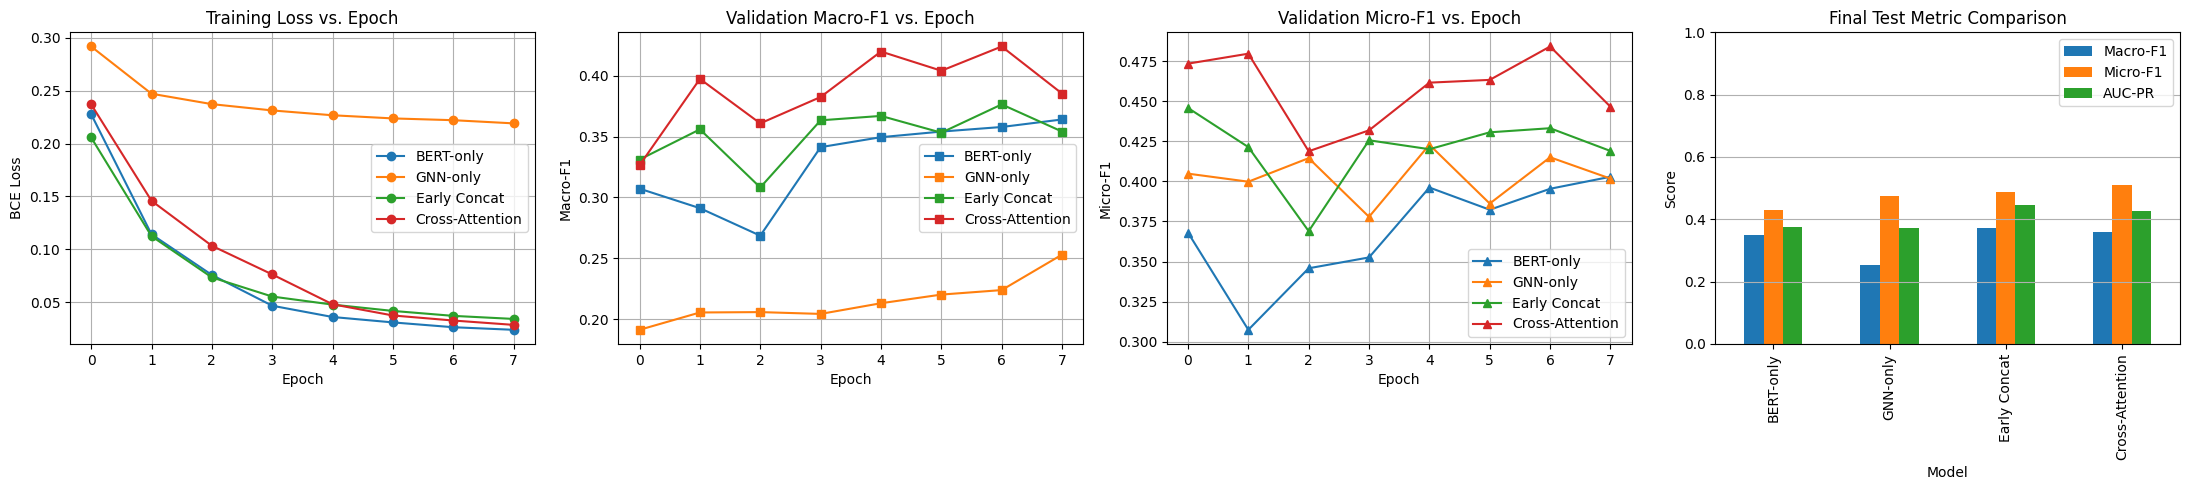

Generating t-SNE projection of Cross-Attention fused embeddings...


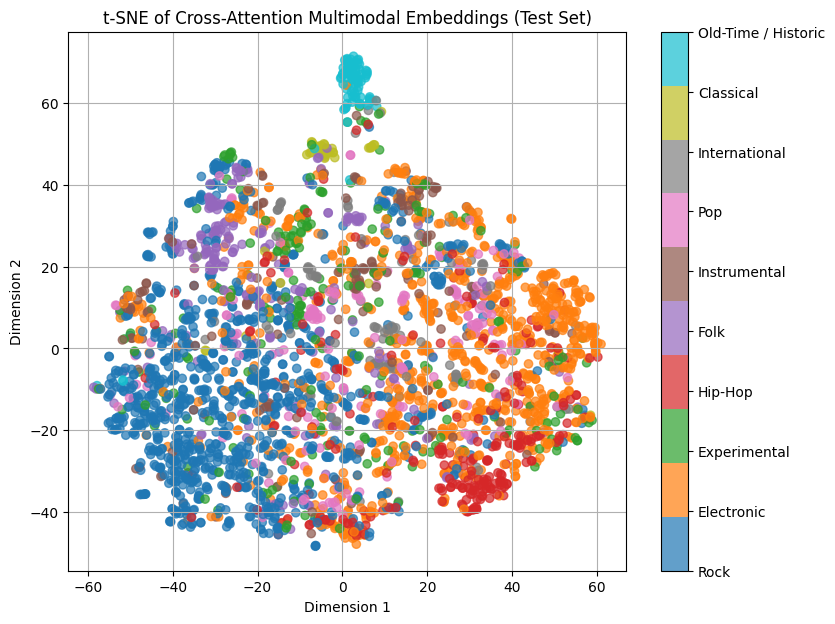

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# 1. Training Loss
for name, res in training_results.items():
    axes[0].plot(res["history"]["train_loss"], marker="o", label=name)
axes[0].set_title("Training Loss vs. Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(True)

# 2. Validation Macro-F1
for name, res in training_results.items():
    axes[1].plot(res["history"]["val_macro_f1"], marker="s", label=name)
axes[1].set_title("Validation Macro-F1 vs. Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].legend()
axes[1].grid(True)

# 3. Validation Micro-F1
for name, res in training_results.items():
    axes[2].plot(res["history"]["val_micro_f1"], marker="^", label=name)
axes[2].set_title("Validation Micro-F1 vs. Epoch")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Micro-F1")
axes[2].legend()
axes[2].grid(True)

# 4. Bar Chart Comparison
comparison_df.set_index("Model")[["Macro-F1", "Micro-F1", "AUC-PR"]].plot(kind="bar", ax=axes[3])
axes[3].set_title("Final Test Metric Comparison")
axes[3].set_ylabel("Score")
axes[3].set_ylim(0, 1.0)
axes[3].grid(True, axis="y")

plt.tight_layout()
plt.savefig("fma_ablation_performance.png", dpi=300)
plt.show()

# 5. t-SNE of Fused Representations
print("Generating t-SNE projection of Cross-Attention fused embeddings...")
model_d = training_results["Cross-Attention"]["model"]
model_d.eval()

all_fused, primary_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        gb = batch["graph_batch"].to(device)
        inp_ids = batch["input_ids"].to(device)
        attn_m = batch["attention_mask"].to(device)
        
        g = model_d.gnn(gb.x, gb.edge_index, gb.batch)
        _, H_text = model_d.bert(inp_ids, attn_m)
        query = g.unsqueeze(1)
        attn_out, _ = model_d.cross_attn(query=query, key=H_text, value=H_text)
        attn_out = model_d.layer_norm(attn_out.squeeze(1))
        z = torch.cat([g, attn_out], dim=-1).cpu().numpy()
        all_fused.append(z)
        
        # Dominant genre
        primary_labels.extend(np.argmax(batch["targets"].numpy(), axis=1))

X_fused = np.vstack(all_fused)
if len(X_fused) > 30:
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_fused)-1))
    X_2d = tsne.fit_transform(X_fused)
    
    plt.figure(figsize=(9, 7))
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=primary_labels, cmap="tab10", alpha=0.7)
    cbar = plt.colorbar(scatter)
    cbar.set_ticks(range(len(class_names)))
    cbar.set_ticklabels(class_names)
    plt.title("t-SNE of Cross-Attention Multimodal Embeddings (Test Set)")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True)
    plt.savefig("fma_cross_attention_tsne.png", dpi=300)
    plt.show()


## Section 20: Qualitative Case Studies
We present at least 3 qualitative case studies from the test set demonstrating:
- Track ID & contextual text input
- Audio graph attributes
- Ground truth target labels
- Model A, B, C, and D predictions


In [21]:
print("=== QUALITATIVE CASE STUDIES ===")
test_dataset = test_loader.dataset

for case_idx in range(min(4, len(test_dataset))):
    item = test_dataset[case_idx]
    tid = item["track_id"]
    row = test_df.loc[tid]
    
    gt_indices = np.where(item["target"].numpy() == 1.0)[0]
    gt_genres = [class_names[idx] for idx in gt_indices]
    
    print(f"\n{'*'*25} CASE STUDY #{case_idx+1} (Track ID: {tid}) {'*'*25}")
    print(f"Text Input:  {row['input_text']}")
    print(f"Graph Info:  Nodes={item['graph'].num_nodes}, Edges={item['graph'].num_edges}")
    print(f"True Labels: {gt_genres}")
    print("Model Predictions:")
    
    for mname in ["BERT-only", "GNN-only", "Early Concat", "Cross-Attention"]:
        probs = training_results[mname]["test_probs"][case_idx]
        pred_indices = np.where(probs >= 0.5)[0]
        pred_genres = [class_names[idx] for idx in pred_indices]
        print(f"  {mname:16s} -> Predicted: {pred_genres} (Max Prob: {probs.max():.3f})")


=== QUALITATIVE CASE STUDIES ===

************************* CASE STUDY #1 (Track ID: 139) *************************
Text Input:  Composition title: CandyAss. Performer: Alec K. Redfearn & the Eyesores. Production arrangement notes: Studio session arrangement. Metrics: 582 plays, 3 favorites, engagement score 702.
Graph Info:  Nodes=6, Edges=30
True Labels: ['Folk']
Model Predictions:
  BERT-only        -> Predicted: ['Rock'] (Max Prob: 0.995)
  GNN-only         -> Predicted: ['Rock'] (Max Prob: 0.671)
  Early Concat     -> Predicted: ['Rock'] (Max Prob: 0.955)
  Cross-Attention  -> Predicted: ['Rock'] (Max Prob: 0.979)

************************* CASE STUDY #2 (Track ID: 140) *************************
Text Input:  Composition title: Queen Of The Wires. Performer: Alec K. Redfearn & the Eyesores. Production arrangement notes: Studio session arrangement. Metrics: 1299 plays, 5 favorites, engagement score 1593.
Graph Info:  Nodes=6, Edges=30
True Labels: ['Folk']
Model Predictions:
  BERT-

In [22]:
print("=== DATA-DRIVEN ABLATION FINDINGS (computed from actual results, not assumed) ===")
best_model = comparison_df.loc[comparison_df["Macro-F1"].idxmax(), "Model"]
print(f"Best model by test Macro-F1: {best_model}")

single_modality = comparison_df[comparison_df["Model"].isin(["BERT-only", "GNN-only"])]
fusion = comparison_df[comparison_df["Model"].isin(["Early Concat", "Cross-Attention"])]
best_single_f1 = single_modality["Macro-F1"].max()
best_fusion_f1 = fusion["Macro-F1"].max()

if best_fusion_f1 > best_single_f1:
    print(f"Fusion helped: best fusion Macro-F1 ({best_fusion_f1:.4f}) > best single-modality Macro-F1 ({best_single_f1:.4f}).")
else:
    print(f"Fusion did NOT help here: best fusion Macro-F1 ({best_fusion_f1:.4f}) <= best single-modality Macro-F1 ({best_single_f1:.4f}).")
    print("Check the 'Audio Coverage Diagnostic' printed earlier — if audio coverage is low/zero, "
          "the GNN branch is trained on synthetic, genre-irrelevant features, which explains this result.")

if audio_file_index is not None and len(audio_file_index) == 0:
    print("\nNOTE: audio_file_index was empty for this run — GNN-only and fusion metrics above "
          "reflect synthetic audio only and should not be interpreted as a real audio ablation.")



=== DATA-DRIVEN ABLATION FINDINGS (computed from actual results, not assumed) ===
Best model by test Macro-F1: Early Concat
Fusion helped: best fusion Macro-F1 (0.3728) > best single-modality Macro-F1 (0.3509).
